4008
9


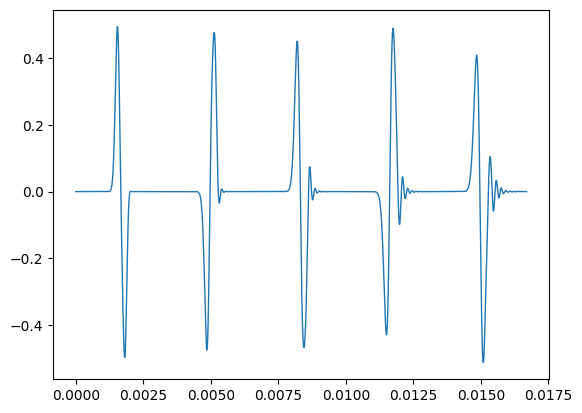

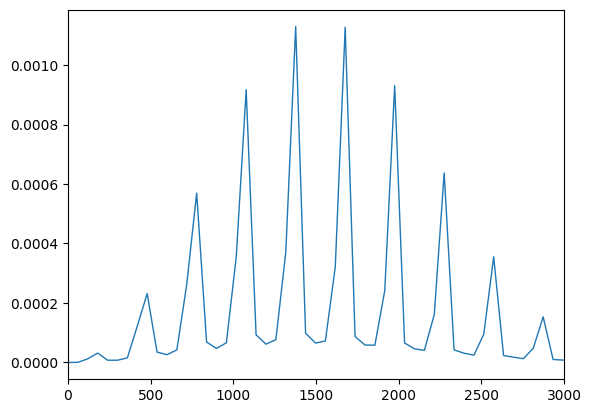

In [ ]:
# Questão 1

import numpy as np
import matplotlib.pyplot as plt


# variáveis globais
c=300. # velocidade do som
L=1. # tamanho da corda
M=200   # número de pontos da grade espacial
delta_x=L/M # espaçamento da grade
delta_t=delta_x/(4*c)
r=c*delta_t/delta_x # parâmetro auxiliar
tfinal=0.0167
N=round(tfinal/delta_t) #1500 # número de passos no tempo
print(N)
y=np.zeros((M+2,3)) # deslocamento vertical
y0=np.zeros(M+2)
yt=np.zeros(N)
x=np.zeros(M+2) # posição horizontal
tempo=np.zeros(N)
k=1000 # parâmetro da largura do pacote inicial
x0=0.5 # posição inicial do pacote
epsilon=0. #1.e-5
Mrig=L/delta_x
paux=epsilon*(Mrig*r)**2
paux2= epsilon*Mrig**2


# configuração da corda em t=0 (que corresponde à n=1)
for i in range(1,M+1):
    x[i]=(i-1)*delta_x
    y[i,1]=np.exp(-k*(x[i]-x0)**2)
y[:,0]=y[:,1]
tempo[0]=0.
tempo[1]=delta_t

iprobe=round(L*0.05/delta_x)-1 #5% da extremidade esquerda
print(iprobe)
yt[0]=y[iprobe,0]
yt[1]=y[iprobe,1]
a=2*(1-r**2)
r2=r**2
for n in range(2,N):
    for i in range(2,M):
        y[i,2]=(a-6*paux)*y[i,1]-y[i,0] \
                +r2*(1+4*paux2)*(y[i+1,1]+y[i-1,1]) \
                -paux*(y[i+2,1]+y[i-2,1])
    y[0,2]=-y[2,2]
    y[M+1,2]=-y[M-1,2]

    yt[n]=y[iprobe,2]
    tempo[n]=n*delta_t
    y[:,0]=y[:,1]
    y[:,1]=y[:,2]

TransFour = np.fft.fft(yt)/N
TransFour = TransFour[range(int(len(yt)/2))]
tpCount     = len(yt)
values      = np.arange(int(tpCount/2))
frequencies = values/(tpCount*delta_t)

PowerSpectrum=np.abs(TransFour)**2

#ax.set_ylim(0,0.0001)
fig,ax=plt.subplots()
line, = ax.plot(tempo, yt, lw=1)

plt.show()


fig,ax=plt.subplots()
ax.set_xlim(0,3000)
line, = ax.plot(frequencies, PowerSpectrum[range(int(len(yt)/2) )], lw=1)

plt.show()

![image.png](attachment:image.png)

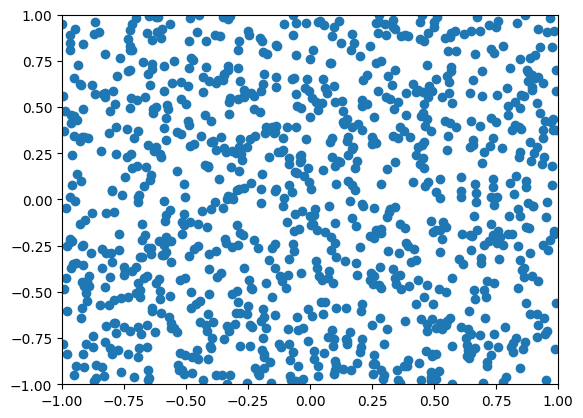

Posição média no início  0.016609837712209648


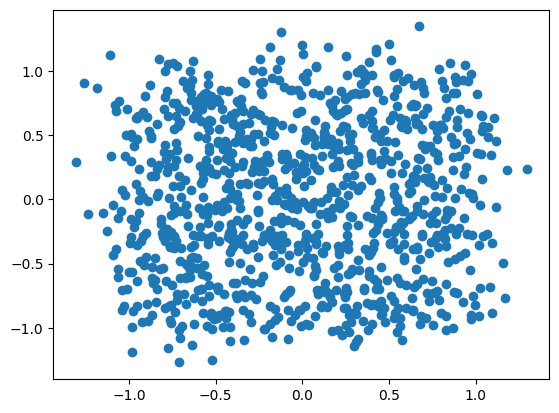

Posição média no fim  0.014421274146925704


In [2]:
# Questão 2

import numpy as np
import matplotlib.pyplot as plt

delta_x=0.01
delta_y=0.01
N=1000
x=2*np.random.rand(N)-1
y=2*np.random.rand(N)-1

plt.xlim(-1,1)
plt.ylim(-1,1)
plt.scatter(x,y)
plt.show()

xm=0
ym=0
for n in range(N):
   xm+=x[n]
   ym+=y[n]

xm/=N
ym/=N
R=np.sqrt(xm**2+ym**2)

print('Posição média no início ',R)



Itempo=200

for i in range(Itempo):
    for n in range(N):
        a = np.random.rand()
        b = np.random.rand()
        if a<0.5:
            x[n]=x[n]+delta_x
        else:
            x[n]=x[n]-delta_x
        if b<0.5:
            y[n]=y[n]+delta_y
        else:
            y[n]=y[n]-delta_y



plt.scatter(x,y)
plt.show()



xm=0
ym=0
for n in range(N):
   xm+=x[n]
   ym+=y[n]

xm/=N
ym/=N
R=np.sqrt(xm**2+ym**2)



print('Posição média no fim ',R)